# DiploDatos 2026
# Entrega 1: Análisis y Visualización
# Predicciones en el espacio: cuantos satelites y desechos podremos tener?

**Grupo:** 

**Integrantes:**

---

## Introducción

Este notebook funciona como una primera aproximación al problema y al dataset. La idea es entender que información tenemos, como esta organizada y que primeras señales aparecen al mirar la composicion general de los objetos orbitales, su evolucion en el tiempo y algunas variables orbitales. Además, se espera que las hipótesis que surjan de los gráficos no queden solo en una lectura visual: cada conclusion relevante deberia complementarse con algun indicador estadístico o prueba de hipótesis que permita respaldarla. También buscamos dejar registradas observaciones útiles para los próximos notebooks de curación, análisis exploratorio maá profundo y modelado.

## Objetivos

- Familiarizarnos con las columnas del dataset y con su significado dentro del problema.
- Realizar una lectura inicial de la estructura, el volumen y el contenido general de los datos.
- Observar la evolución temporal de los objetos registrados y su crecimiento acumulado.
- Describir el comportamiento de variables orbitales clave como PERIOD, INCLINATION, APOGEE y PERIGEE.
- Detectar indicios de faltantes, outliers o decisiones de curacion que convendra retomar mas adelante.
- Dejar planteadas hipótesis y preguntas para las siguientes etapas del trabajo.
- Respaldar las principales afirmaciones con indicadores estadisticos y, cuando corresponda, con pruebas de hipótesis sencillas acordes al tipo de variable analizada.

## Preguntas guía

- Cuantos registros y cuantas variables contiene el dataset?
- Qué columnas parecen más relevantes para entender el problema desde el inicio?
- Cómo evoluciono la cantidad de objetos lanzados por ano y que tan rapido crece el acumulado historico?
- Qué forma toman las principales variables orbitales y que valores extremos aparecen a simple vista?
- Qué faltantes o decisiones de limpieza conviene dejar anotados para el siguiente notebook?
- Qué hipotesis iniciales surgen a partir de esta primera inspeccion?
- Cómo podrian ponerse a prueba esas hipotesis con estadisticos descriptivos, intervalos de confianza o tests de comparacion?

## 1. Preparacion del ambiente

Cargamos las librerias necesarias para una primera exploracion. La idea es trabajar con un flujo simple y reproducible, de modo que cada tabla o grafico pueda reconstruirse facilmente a partir del archivo original.

In [1]:
# Import necessary libraries
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Set display options for pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Define the path to the data file
DATA_PATH = Path("../data/raw/satellites_202602.csv")

## 2. Ingesta de datos

En esta seccion leemos el archivo fuente y hacemos una inspeccion inicial de dimensiones, tipos de datos y primeros registros. Todavia no aplicamos transformaciones: primero buscamos entender con que informacion contamos.

In [2]:
# Load the data from the CSV file
data = pd.read_csv(DATA_PATH)

print(f"Filas: {data.shape[0]}")
print(f"Columnas: {data.shape[1]}")
data.head(10)

Filas: 59997
Columnas: 26


,INTLDES,NORAD_CAT_ID,OBJECT_TYPE,SATNAME,COUNTRY,LAUNCH,SITE,DECAY,PERIOD,INCLINATION,APOGEE,PERIGEE,COMMENT,COMMENTCODE,RCSVALUE,RCS_SIZE,FILE,LAUNCH_YEAR,LAUNCH_NUM,LAUNCH_PIECE,CURRENT,OBJECT_NAME,OBJECT_ID,OBJECT_NUMBER,ACTIVE,PURPOSE
0,1957-001B,2,PAYLOAD,SPUTNIK 1,CIS,1957-10-04,TTMTR,1958-01-03,96.10,65.00,1080.00,64.00,NaN,NaN,0,NaN,7179,1957,1,B,Y,SPUTNIK 1,1957-001B,2,No,Technology Development
1,1957-002A,3,PAYLOAD,SPUTNIK 2,CIS,1957-11-03,TTMTR,1958-04-14,103.74,65.33,1659.00,211.00,NaN,NaN,0,SMALL,9221,1957,2,A,Y,SPUTNIK 2,1957-002A,3,No,Technology Development
2,1958-001A,4,PAYLOAD,EXPLORER 1,US,1958-02-01,AFETR,1970-03-31,88.48,33.15,215.00,183.00,NaN,NaN,0,NaN,1,1958,1,A,Y,EXPLORER 1,1958-001A,4,No,Technology Development
3,1958-002B,5,PAYLOAD,VANGUARD 1,US,1958-03-17,AFETR,NaN,132.60,34.25,3819.00,653.00,NaN,NaN,0,SMALL,9410,1958,2,B,Y,VANGUARD 1,1958-002B,5,No,Technology Development
4,1958-002C,1576,DEBRIS,VANGUARD DEB,US,1958-03-17,AFETR,NaN,121.78,34.22,2885.00,636.00,NaN,NaN,0,SMALL,9409,1958,2,C,Y,VANGUARD DEB,1958-002C,1576,No,NaN
5,1958-003A,6,PAYLOAD,EXPLORER 3,US,1958-03-26,AFETR,1958-06-28,151.74,19.24,5985.00,107.00,NaN,5.00,0,SMALL,9295,1958,3,A,Y,EXPLORER 3,1958-003A,6,No,Technology Development
6,1958-004B,8,PAYLOAD,SPUTNIK 3,CIS,1958-05-15,TTMTR,1960-04-06,88.43,65.06,255.00,139.00,NaN,NaN,0,LARGE,1,1958,4,B,Y,SPUTNIK 3,1958-004B,8,No,Technology Development
7,1958-005A,9,PAYLOAD,EXPLORER 4,US,1958-07-26,AFETR,1959-10-23,92.81,50.25,585.00,239.00,NaN,NaN,0,NaN,1,1958,5,A,Y,EXPLORER 4,1958-005A,9,No,Technology Development
8,1958-006A,10,PAYLOAD,SCORE,US,1958-12-18,AFETR,1959-01-21,98.21,32.29,1187.00,159.00,NaN,NaN,0,NaN,1,1958,6,A,Y,SCORE,1958-006A,10,No,Technology Development
9,1958-007A,110,PAYLOAD,PIONEER 1,US,1958-10-11,AFETR,1958-10-12,NaN,NaN,NaN,NaN,NO INITIAL ELEMENTS,NaN,0,NaN,9278,1958,7,A,Y,PIONEER 1,1958-007A,110,No,Technology Development


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 59997 entries, 0 to 59996
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   INTLDES        59997 non-null  str    
 1   NORAD_CAT_ID   59997 non-null  int64  
 2   OBJECT_TYPE    59997 non-null  str    
 3   SATNAME        59997 non-null  str    
 4   COUNTRY        59997 non-null  str    
 5   LAUNCH         59997 non-null  str    
 6   SITE           59997 non-null  str    
 7   DECAY          29940 non-null  str    
 8   PERIOD         59236 non-null  float64
 9   INCLINATION    59236 non-null  float64
 10  APOGEE         59236 non-null  float64
 11  PERIGEE        59236 non-null  float64
 12  COMMENT        745 non-null    str    
 13  COMMENTCODE    4085 non-null   float64
 14  RCSVALUE       59997 non-null  int64  
 15  RCS_SIZE       49289 non-null  str    
 16  FILE           59997 non-null  int64  
 17  LAUNCH_YEAR    59997 non-null  int64  
 18  LAUNCH_NUM     59

## 3. Lectura inicial del dataset

### Columnas relevantes para iniciar el analisis

Despues de revisar la estructura general, estas son algunas variables que conviene seguir de cerca desde el comienzo:

- OBJECT_TYPE: tipo de objeto registrado, principalmente PAYLOAD o DEBRIS.
- ACTIVE: estado operativo del objeto, relevante para futuras tareas de clasificacion.
- COUNTRY: pais u organizacion responsable.
- LAUNCH y LAUNCH_YEAR: fecha y año de lanzamiento.
- DECAY: fecha de reentrada o decaimiento orbital, cuando esta disponible.
- PERIOD, INCLINATION, APOGEE, PERIGEE: parametros orbitales.
- RCS_SIZE y RCSVALUE: medidas asociadas al tamaño estimado del objeto.
- PURPOSE: proposito de mision, util para enriquecer la interpretación en etapas posteriores.

### Que conviene dejar registrado en esta etapa

- Describir que tipos de objetos dominan el dataset y si hay categorias claramente mayoritarias.
- Revisar si ACTIVE aparece balanceada o no, aun cuando en este notebook solo la miremos de forma descriptiva.
- Anotar por que estas proporciones pueden influir mas adelante en las decisiones de modelado y evaluacion.
- Si afirman que una categoria domina claramente o que existe desbalance, justificarlo con porcentajes, razones o algun contraste simple de proporciones.

## 4. Evolución temporal

El eje temporal es central para el problema porque permite ver como crece la actividad orbital a lo largo de los anos. Mirar la cantidad de objetos por año y su acumulado historico ayuda a dimensionar la escala del fenomeno y a detectar posibles cambios recientes en la dinamica de lanzamientos.

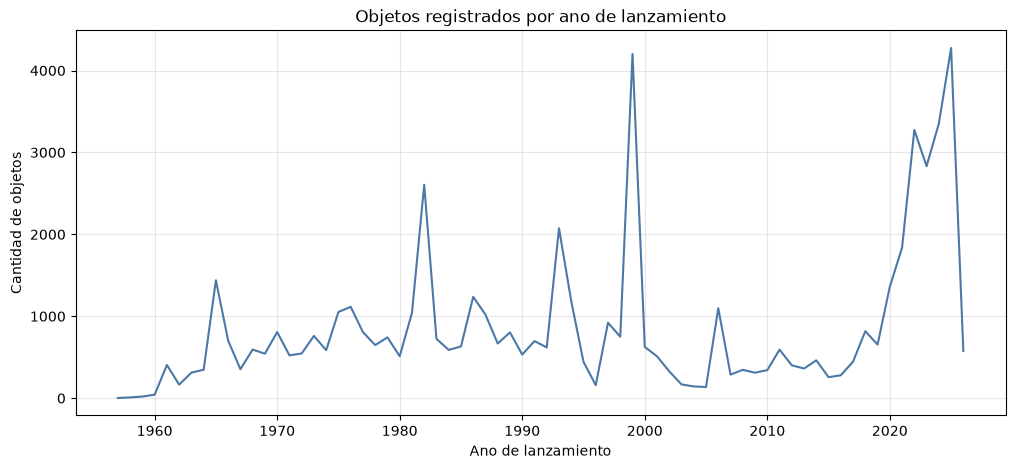

In [ ]:
launches_by_year = data.groupby("LAUNCH_YEAR").size()

fig, ax = plt.subplots(figsize=(12, 5))
launches_by_year.plot(ax=ax, color="#4C78A8")
ax.set_title("Objetos registrados por año de lanzamiento")
ax.set_xlabel("Ano de lanzamiento")
ax.set_ylabel("Cantidad de objetos")
ax.grid(True, alpha=0.3)
plt.show()

In [1]:
fig, ax = plt.subplots(figsize=(12, 5))
launches_by_year.cumsum().plot(ax=ax, color="#72B7B2")
ax.set_title("Acumulado historico de objetos registrados")
ax.set_xlabel("Año de lanzamiento")
ax.set_ylabel("Cantidad acumulada")
ax.grid(True, alpha=0.3)
plt.show()

NameError: name 'plt' is not defined

### Pistas para la interpretacion

- Identificar periodos de crecimiento acelerado o cambios notorios en la tendencia.
- Comparar el comportamiento reciente con las decadas anteriores para ver si cambia la escala del problema.
- Registrar hipótesis sobre posibles causas del crecimiento observado, siempre separando interpretacion de evidencia.
- Si sostienen que hubo un cambio en la tendencia entre periodos, respaldarlo con comparaciones de medias, medianas, tasas de crecimiento o el test que consideren adecuado.

## 5. Variables orbitales

Las variables orbitales pueden aportar informacion valiosa para entender en que condiciones se encuentran los objetos y como se distribuyen en distintas orbitas. En esta primera pasada las observamos de forma descriptiva; el tratamiento de outliers, escalado y transformaciones queda para los siguientes notebooks.

In [9]:
orbital_cols = ["PERIOD", "INCLINATION", "APOGEE", "PERIGEE"]
data[orbital_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PERIOD,59236.00,162.94,620.07,0.00,89.54,94.11,100.43,95687.68
INCLINATION,59236.00,69.70,24.33,0.00,53.05,70.41,96.79,150.93
APOGEE,59236.00,2910.11,11600.38,0.00,280.00,483.00,835.00,638523.00
PERIGEE,59236.00,1623.48,6339.27,0.00,212.00,453.00,660.25,314973.00


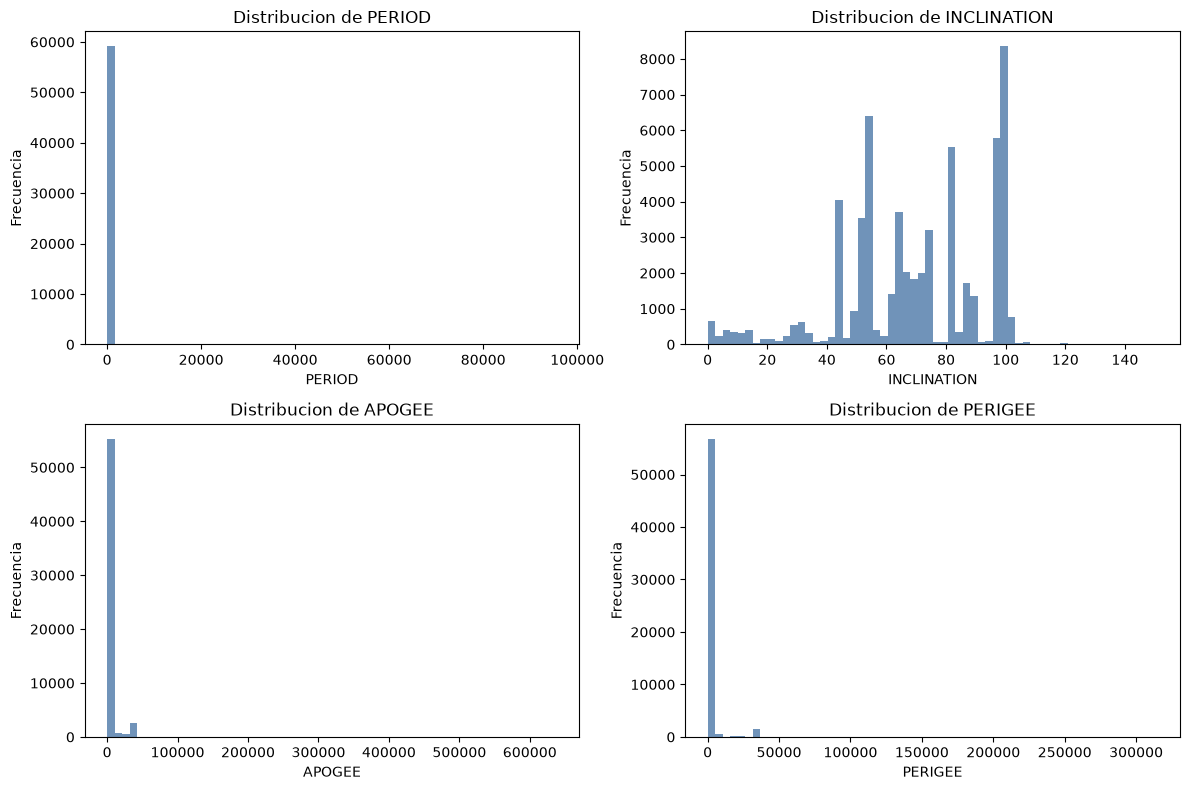

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.ravel(), ["PERIOD", "INCLINATION", "APOGEE", "PERIGEE"]):
    data[col].dropna().plot(kind="hist", bins=60, ax=ax, color="#4C78A8", alpha=0.8)
    ax.set_title(f"Distribucion de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### Que observar en estas distribuciones

- Identificar distribuciones concentradas, sesgadas o con valores extremos evidentes.
- Senalar que variables parecen necesitar una revision mas cuidadosa de outliers o escalas.
- Registrar si alguna variable orbital sugiere una segmentacion natural que pueda explorarse despues.

## 6. Pistas para la curacion de datos

Aunque todavia no hacemos una curacion formal, este punto sirve para dejar anotadas senales que ya aparecen en la inspeccion inicial.

- Elegir columnas con faltantes relevantes y discutir si esas ausencias parecen esperables o problematicas.
- Separar posibles errores de carga de ausencias propias del dominio o de la forma en que se registra cada objeto.
- Registrar decisiones pendientes para el notebook de analisis exploratorio y curacion.
- Indicar tambien que variables podrian requerir transformaciones o chequeos adicionales antes de aplicar tests estadisticos.

## 7. Entregables esperados

Al finalizar este notebook, el grupo deberia poder entregar:

- Una descripcion breve del dataset y de las variables mas importantes para el objetivo del proyecto.
- Visualizaciones interpretadas, no solo generadas, que ayuden a contar una historia del conjunto de datos.
- Un analisis temporal de lanzamientos y crecimiento acumulado de objetos.
- Una lectura descriptiva de las principales variables orbitales.
- Al menos dos hipotesis explicitamente formuladas y contrastadas con algun indicador estadistico o test adecuado.
- Una lista de problemas de datos, faltantes o decisiones pendientes para el proximo notebook.
- Un conjunto inicial de hipotesis para validar mediante curacion, ingenieria de variables o modelado.

## 8. Puente hacia los proximos notebooks

Para el notebook de **analisis exploratorio y curacion de datos**, conviene dejar identificadas las columnas que requieren revision: fechas, faltantes, valores extremos, categorias poco frecuentes, variables redundantes, codificacion de PURPOSE y posible definicion de variables derivadas. Tambien es importante dejar asentado que supuestos habria que revisar antes de aplicar pruebas estadisticas con mayor formalidad.

Para el notebook de **aprendizaje supervisado, no supervisado, o ambos**, la idea es dejar planteadas hipotesis predictivas o de segmentacion: por ejemplo, si LAUNCH_YEAR, OBJECT_TYPE, COUNTRY, PURPOSE, RCS_SIZE o los parametros orbitales parecen asociarse con ACTIVE o con grupos naturales de objetos. En esta entrega, esas asociaciones deberian empezar a justificarse no solo con graficos sino tambien con evidencia estadistica basica.